# POOD Dataset Purification EBM vs DM-DDPM

## Neural Tangent

In [172]:
import pandas as pd
pd.options.mode.chained_assignment = None  # default='warn'
import json
import numpy as np

df = pd.read_csv('/Users/sunaybhat/Documents/GitHub/Results/Poison_Defense/From_Scratch/NeuralTangent/POOD.csv')

filters = {
            # 'Baseline':{'Data Key': 'Baseline'},
            # 'JPEG_25':{'Data Key': 'JPEG[25]'},
            'EBM_cinic10_imagenet-1000':{'Data Key': 'EBM[cinic10_imagenet_nf[32]]_Steps[1000]_T[0.0001]'},
            'EBM_cinic10_imagenet-750':{'Data Key': 'EBM[cinic10_imagenet_nf[32]]_Steps[750]_T[0.0001]'},
            'EBM_cinic10_imagenet-500':{'Data Key': 'EBM[cinic10_imagenet_nf[32]]_Steps[500]_T[0.0001]'},
            'EBM_cinic10_imagenet-150':{'Data Key': 'EBM[cinic10_imagenet_nf[32]]_Steps[150]_T[0.0001]'},
            'EBM_cifar10-1000':{'Data Key': 'EBM[cifar10_nf[32]]_Steps[1000]_T[0.0001]'},
            'EBM_cifar10-750':{'Data Key': 'EBM[cifar10_nf[32]]_Steps[750]_T[0.0001]'},
            'EBM_cifar10-500':{'Data Key': 'EBM[cifar10_nf[32]]_Steps[500]_T[0.0001]'},
            'EBM_cifar10-150':{'Data Key': 'EBM[cifar10_nf[32]]_Steps[150]_T[0.0001]'},
            'EBM_office_home-1000':{'Data Key': 'EBM[office_home_nf[32]]_Steps[1000]_T[0.0001]'},
            'EBM_office_home-750':{'Data Key': 'EBM[office_home_nf[32]]_Steps[750]_T[0.0001]'},
            'EBM_office_home-500':{'Data Key': 'EBM[office_home_nf[32]]_Steps[500]_T[0.0001]'},
            'EBM_office_home-150':{'Data Key': 'EBM[office_home_nf[32]]_Steps[150]_T[0.0001]'},
            'EBM_textures-1000':{'Data Key': 'EBM[textures_nf[32]]_Steps[1000]_T[0.0001]'},
            'EBM_textures-750':{'Data Key': 'EBM[textures_nf[32]]_Steps[750]_T[0.0001]'},
            'EBM_textures-500':{'Data Key': 'EBM[textures_nf[32]]_Steps[500]_T[0.0001]'},
            'EBM_textures-150':{'Data Key': 'EBM[textures_nf[32]]_Steps[150]_T[0.0001]'},
            'EBM_lfw_people-1000':{'Data Key': 'EBM[lfw_people_nf[32]]_Steps[1000]_T[0.0001]'},
            'EBM_lfw_people-750':{'Data Key': 'EBM[lfw_people_nf[32]]_Steps[750]_T[0.0001]'},
            'EBM_lfw_people-500':{'Data Key': 'EBM[lfw_people_nf[32]]_Steps[500]_T[0.0001]'},
            'EBM_lfw_people-150':{'Data Key': 'EBM[lfw_people_nf[32]]_Steps[150]_T[0.0001]'},
            'EBM_flowers102-1000':{'Data Key': 'EBM[flowers102_nf[32]]_Steps[1000]_T[0.0001]'},
            'EBM_flowers102-750':{'Data Key': 'EBM[flowers102_nf[32]]_Steps[750]_T[0.0001]'},
            'EBM_flowers102-500':{'Data Key': 'EBM[flowers102_nf[32]]_Steps[500]_T[0.0001]'},
            'EBM_flowers102-150':{'Data Key': 'EBM[flowers102_nf[32]]_Steps[150]_T[0.0001]'},
            'DM DDPM_cifar10-150':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[L]]_T[150]'},
            'DM DDPM_cifar10-125':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[L]]_T[125]'},
            'DM DDPM_cifar10-100':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[L]]_T[100]'},
            'DM DDPM_cifar10-75':{'Data Key': 'DM_UNET[cifar10_DDPM[250]_nf[L]]_T[75]'},
            'DM DDPM_cinic10_imagenet-150':{'Data Key': 'DM_UNET[cinic10_imagenet_DDPM[250]_nf[L]]_T[150]'},
            'DM DDPM_cinic10_imagenet-125':{'Data Key': 'DM_UNET[cinic10_imagenet_DDPM[250]_nf[L]]_T[125]'},
            'DM DDPM_cinic10_imagenet-100':{'Data Key': 'DM_UNET[cinic10_imagenet_DDPM[250]_nf[L]]_T[100]'},
            'DM DDPM_cinic10_imagenet-75':{'Data Key': 'DM_UNET[cinic10_imagenet_DDPM[250]_nf[L]]_T[75]'},
            'DM DDPM_office_home-150':{'Data Key': 'DM_UNET[office_home_DDPM[250]_nf[L]]_T[150]'},
            'DM DDPM_office_home-125':{'Data Key': 'DM_UNET[office_home_DDPM[250]_nf[L]]_T[125]'},
            'DM DDPM_office_home-100':{'Data Key': 'DM_UNET[office_home_DDPM[250]_nf[L]]_T[100]'},
            'DM DDPM_office_home-75':{'Data Key': 'DM_UNET[office_home_DDPM[250]_nf[L]]_T[75]'},
            'DM DDPM_textures-150':{'Data Key': 'DM_UNET[textures_DDPM[250]_nf[L]]_T[150]'},
            'DM DDPM_textures-125':{'Data Key': 'DM_UNET[textures_DDPM[250]_nf[L]]_T[125]'},
            'DM DDPM_textures-100':{'Data Key': 'DM_UNET[textures_DDPM[250]_nf[L]]_T[100]'},
            'DM DDPM_textures-75':{'Data Key': 'DM_UNET[textures_DDPM[250]_nf[L]]_T[75]'},
            'DM DDPM_lfw_people-150':{'Data Key': 'DM_UNET[lfw_people_DDPM[250]_nf[L]]_T[150]'},
            'DM DDPM_lfw_people-125':{'Data Key': 'DM_UNET[lfw_people_DDPM[250]_nf[L]]_T[125]'},
            'DM DDPM_lfw_people-100':{'Data Key': 'DM_UNET[lfw_people_DDPM[250]_nf[L]]_T[100]'},
            'DM DDPM_lfw_people-75':{'Data Key': 'DM_UNET[lfw_people_DDPM[250]_nf[L]]_T[75]'},
            'DM DDPM_flowers102-150':{'Data Key': 'DM_UNET[flowers102_DDPM[250]_nf[L]]_T[150]'},
            'DM DDPM_flowers102-125':{'Data Key': 'DM_UNET[flowers102_DDPM[250]_nf[L]]_T[125]'},
            'DM DDPM_flowers102-100':{'Data Key': 'DM_UNET[flowers102_DDPM[250]_nf[L]]_T[100]'},
            'DM DDPM_flowers102-75':{'Data Key': 'DM_UNET[flowers102_DDPM[250]_nf[L]]_T[75]'},
}

df_results = []
for label, filter_dict in filters.items():

    df_filt = df
    for key, value in filter_dict.items():
        if value == 'NaN':
            df_filt = df_filt[df_filt[key].isnull()]
        else:
            df_filt = df_filt[df_filt[key] == value]


    df_results.append({'Defense': label,
                        'Nat Acc': f"{df_filt['End Acc'].mean()*100:.2f} \u00B1 {df_filt['End Acc'].std()*100:.2f}",
                    'Num Results': len(df_filt),
                    })
        
df_results = pd.DataFrame(df_results)
# df_results

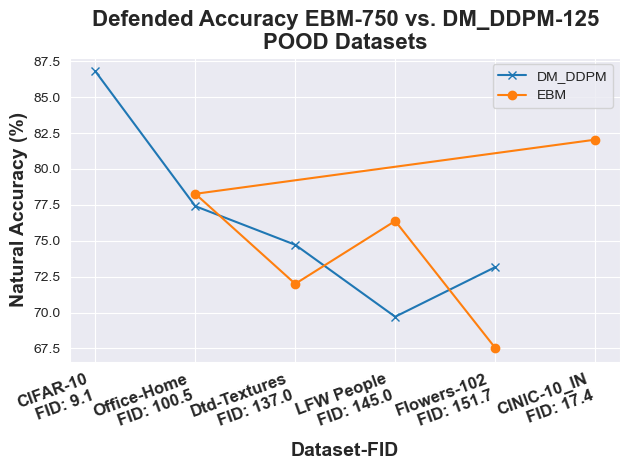

In [173]:
dataset_dict = {
    'cifar10': 'CIFAR-10',
    'cinic10_imagenet': 'CINIC-10_IN',
    'office_home': 'Office-Home',
    'textures': 'Dtd-Textures',
    'lfw_people': 'LFW People',
    'flowers102': 'Flowers-102',
}

dataset_fids = pd.read_csv('/Users/sunaybhat/Documents/GitHub/Results/Poison_Defense/dataset_FIDs.csv')
dataset_fids['fids'] = dataset_fids['fid_score_mean'].apply(lambda x: float(x.split('±')[0]))
dataset_fids = dataset_fids.set_index('ood_dataset')['fids'].to_dict()

dm_plot = df_results.copy()
dm_plot['Label'] = dm_plot['Defense'].apply(lambda x: x.split('_')[0])
dm_plot['Dataset'] = dm_plot['Defense'].apply(lambda x: '_'.join(x.split('-')[0].split('_')[1:]))
dm_plot['FIDs'] = dm_plot['Dataset'].apply(lambda x: dataset_fids[x])
dm_plot['Dataset'] = dm_plot['Dataset'].apply(lambda x: dataset_dict[x])
dm_plot['Steps'] = dm_plot['Defense'].apply(lambda x: int(x.split('-')[1]) if len(x.split('-')) > 1 else 0)
dm_plot['Nat Acc Mean'] = dm_plot['Nat Acc'].apply(lambda x: float(x.split(' ')[0]))

# EBM Plot
dm_plot_ebm = dm_plot[(dm_plot['Steps'] == 500) & (dm_plot['Label'] == 'EBM')]
dm_plot_pivot_ebm = dm_plot_ebm.pivot_table(index='Label', columns=['FIDs','Dataset'], values='Nat Acc Mean')
# Combine column levels into one
dm_plot_pivot_ebm.columns = [f'{x[1]}\nFID: {x[0]:.1f}' for x in dm_plot_pivot_ebm.columns]

# DM_DDPM Plot
dm_plot_dm = dm_plot[(dm_plot['Steps'] == 125) & (dm_plot['Label'] == 'DM DDPM')]
dm_plot_pivot_dm = dm_plot_dm.pivot_table(index='Label', columns=['FIDs','Dataset'], values='Nat Acc Mean')
# Combine column levels into one
dm_plot_pivot_dm.columns = [f'{x[1]}\nFID: {x[0]:.1f}' for x in dm_plot_pivot_dm.columns]


# Replace X labels with f'{Dataset}-FID:{FID}'
plt.plot(dm_plot_pivot_dm.columns, dm_plot_pivot_dm.values[0], marker='x', label='DM_DDPM')
plt.plot(dm_plot_pivot_ebm.columns, dm_plot_pivot_ebm.values[0], marker='o', label='EBM')
# Roate X labels
plt.xticks(rotation=20, ha='right',fontweight='bold',fontsize=12)
plt.ylabel('Natural Accuracy (%)',fontweight='bold',fontsize=14)
plt.xlabel('Dataset-FID',fontweight='bold',fontsize=14)
plt.title('Defended Accuracy EBM-750 vs. DM_DDPM-125\nPOOD Datasets',fontweight='bold',fontsize=16)
plt.legend()

plt.tight_layout()


In [175]:
dm_plot_pivot_ebm

,CINIC-10_IN\nFID: 17.4,Office-Home\nFID: 100.5,Dtd-Textures\nFID: 137.0,LFW People\nFID: 145.0,Flowers-102\nFID: 151.7
Label,,,,,
EBM,82.04,78.27,72.0,76.38,67.55


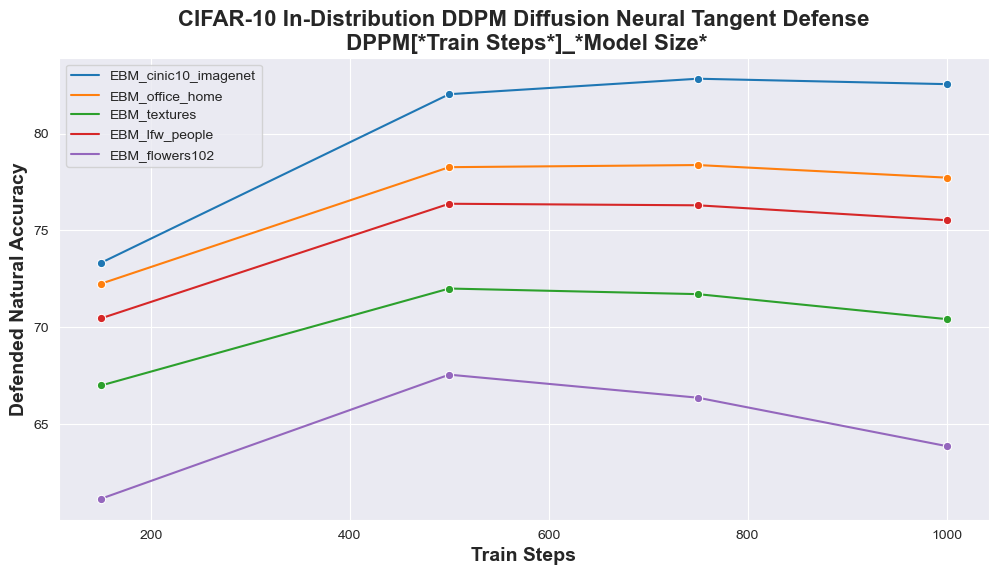

In [162]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")

# Filter for EBM or DM
dm_plot = df_results[df_results['Defense'].str.contains('EBM')]
dm_plot['Label'] = dm_plot['Defense'].apply(lambda x: x.split('-')[0])
dm_plot['Steps'] = dm_plot['Defense'].apply(lambda x: int(x.split('-')[1]) if len(x.split('-')) > 1 else 0)
dm_plot['Nat Acc Mean'] = dm_plot['Nat Acc'].apply(lambda x: float(x.split(' ')[0]))

# Filter out 0 steps
dm_plot_diff = dm_plot[dm_plot['Steps'] != 0]

# PLot x_axis steps, y axis Nat Acc, and hue as Label
plt.figure(figsize=(12, 6))
sns.lineplot(data=dm_plot_diff, x='Steps', y='Nat Acc Mean', hue='Label', marker='o',palette='tab10')

# # Draw Hlines for EBM and JPEG and No Defense
# plt.axhline(y=dm_plot[dm_plot['Defense'] == 'JPEG_25']['Nat Acc Mean'].values[0], color='r', linestyle='--', label='JPEG')
# plt.axhline(y=dm_plot[dm_plot['Defense'] == 'EBM_1000']['Nat Acc Mean'].values[0], color='g', linestyle='--', label='EBM')

plt.title('CIFAR-10 In-Distribution DDPM Diffusion Neural Tangent Defense\n DPPM[*Train Steps*]_*Model Size*',fontsize=16, fontweight='bold')
plt.xlabel('Train Steps', fontsize=14, fontweight='bold')
plt.ylabel('Defended Natural Accuracy', fontsize=14, fontweight='bold')
plt.legend()

# plt.savefig('CIFAR-10 In-Distribution DDPM Diffusion Neural Tangent Defense.pdf', dpi=300,bbox_inches='tight')

In [147]:
dm_plot

,Defense,Nat Acc,Num Results,Label,Steps,Nat Acc Mean
20,DM DDPM_cifar10-150,86.25 ± 0.25,8,DM DDPM_cifar10,150,86.25
21,DM DDPM_cifar10-125,86.80 ± 0.20,8,DM DDPM_cifar10,125,86.80
22,DM DDPM_cifar10-100,86.98 ± 0.28,8,DM DDPM_cifar10,100,86.98
23,DM DDPM_cifar10-75,86.71 ± 0.29,8,DM DDPM_cifar10,75,86.71
24,DM DDPM_office_home-150,75.73 ± 0.33,8,DM DDPM_office_home,150,75.73
25,DM DDPM_office_home-125,77.41 ± 0.35,8,DM DDPM_office_home,125,77.41
26,DM DDPM_office_home-100,79.14 ± 0.24,8,DM DDPM_office_home,100,79.14
27,DM DDPM_office_home-75,80.44 ± 0.53,8,DM DDPM_office_home,75,80.44
28,DM DDPM_textures-150,72.37 ± 0.48,8,DM DDPM_textures,150,72.37
29,DM DDPM_textures-125,74.72 ± 0.35,8,DM DDPM_textures,125,74.72
